# HAM10000 Exploratory Data Analysis (EDA)

This notebook explores the HAM10000 skin lesion dataset before model training.

Objectives:
- Explore the metadata
- Analyze missing values
- Visualize class distribution
- Examine demographic information
- Display sample images
- Summarize key observations


In [1]:
# Import Libraries
import os

import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
# Load Metadata
df = pd.read_csv("data/HAM10000_metadata.csv")

In [3]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
df.shape

(10015, 7)

In [5]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [6]:
df.dtypes

lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [8]:
df.describe(include='all')

,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0000835,ISIC_0032258,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


In [9]:
# Missing Values
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Observations:
- The dataset contains 57 missing values in the age column.
- All other metadata fields (lesion_id, image_id, dx, dx_type, sex, and localization) are complete with no missing values.
- The missing age values may need to be handled during preprocessing, for example by removing those records or imputing the missing ages if age is used as a model feature.


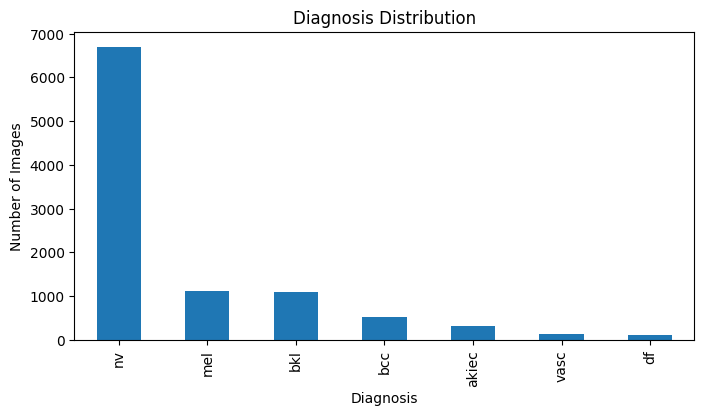

In [11]:
# Diagnosis Distribution
df["dx"].value_counts().plot(kind="bar", figsize=(8, 4))

plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")
plt.show()

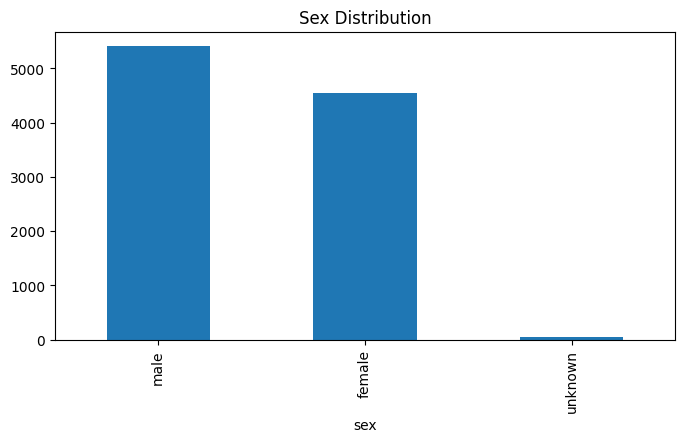

In [12]:
# Sex Distribution
df["sex"].value_counts().plot(kind="bar", figsize=(8, 4))

plt.title("Sex Distribution")
plt.show()

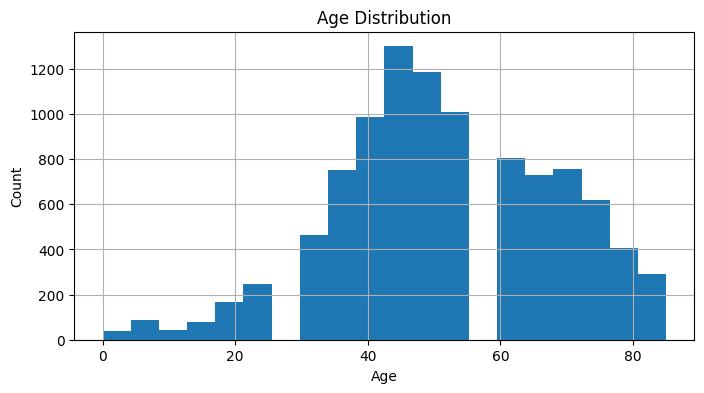

In [13]:
# Age Distribution
df["age"].hist(bins=20 ,  figsize=(8, 4))

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

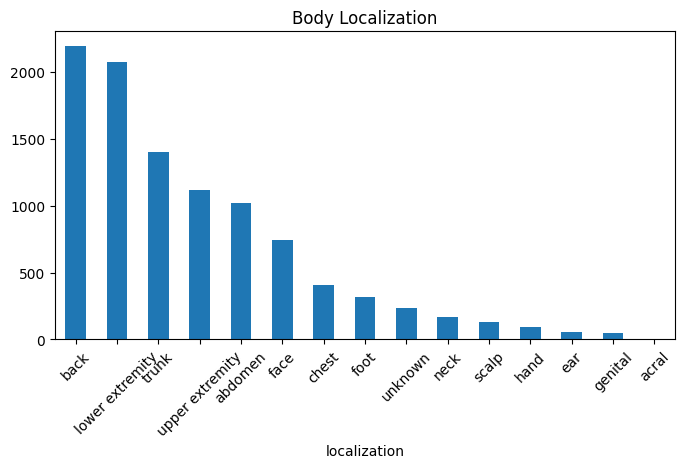

In [14]:
# Body Localization
df["localization"].value_counts().plot(kind="bar" , figsize=(8, 4))

plt.title("Body Localization")

plt.xticks(rotation=45)

plt.show()

In [17]:
# Display Sample Images
# So Build a Dictionary of Image Paths

image_dirs = [
    "data/HAM10000_images_part_1",
    "data/HAM10000_images_part_2"
]

image_paths = {}

for folder in image_dirs:
    for file in os.listdir(folder):
        if file.endswith(".jpg"):
            image_id = file[:-4]
            image_paths[image_id] = os.path.join(folder, file)
            

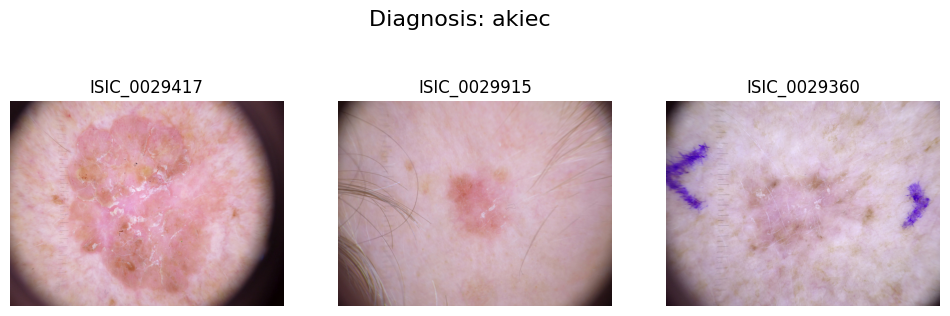

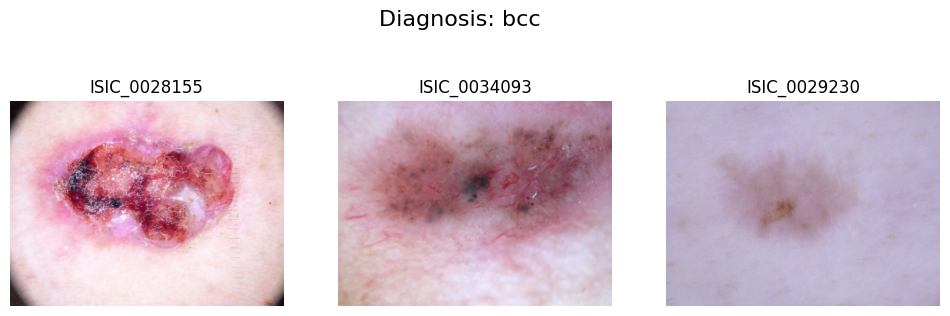

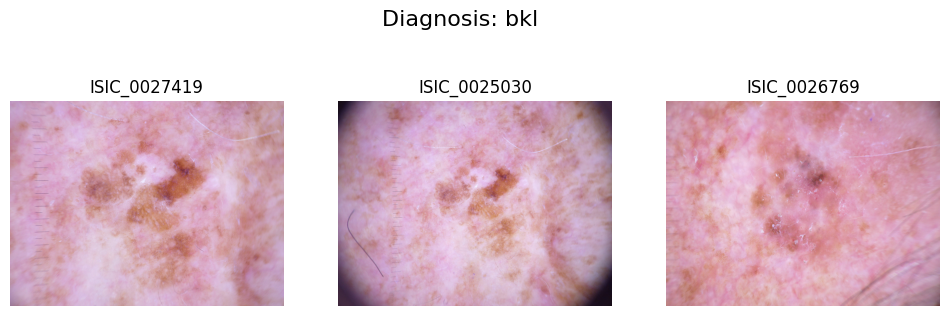

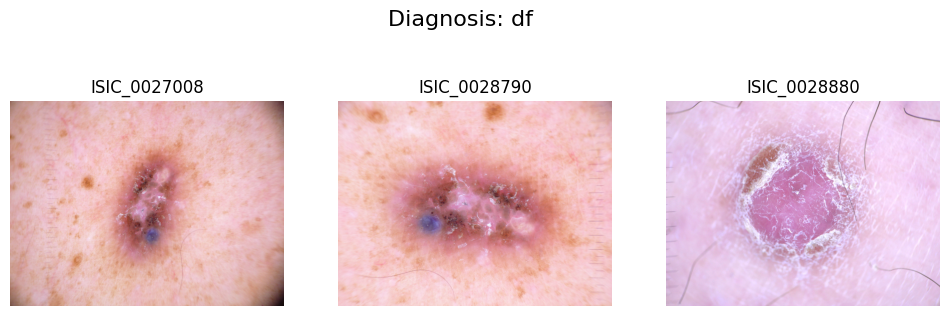

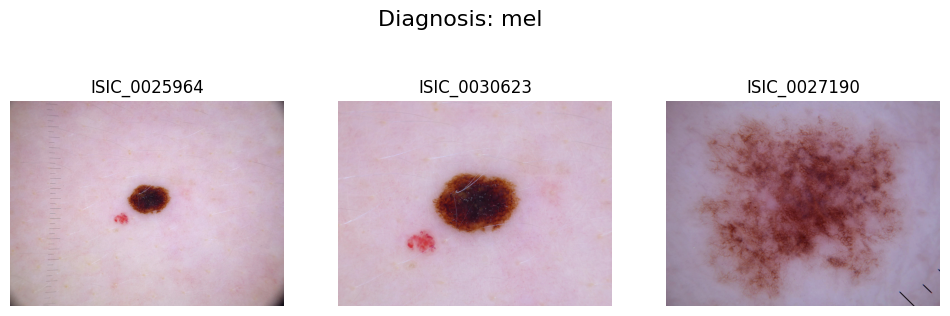

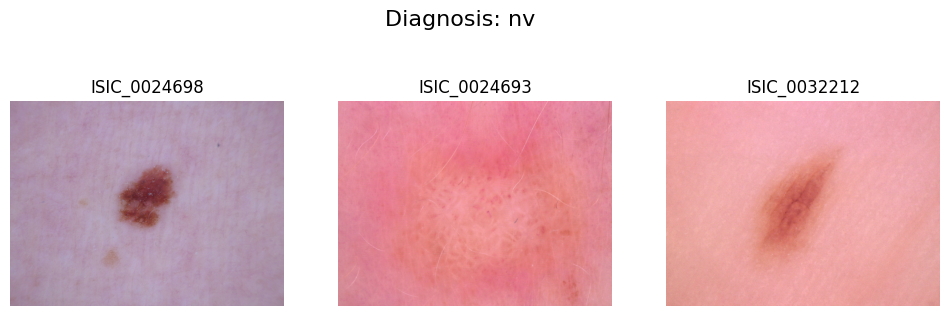

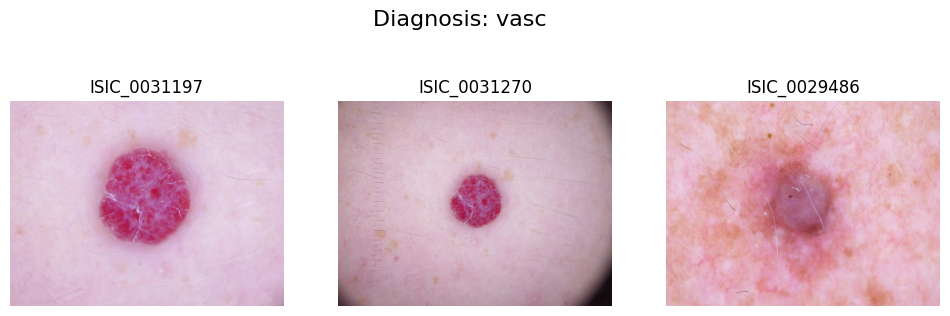

In [18]:
# Display 3 images from each diagnosis class
diagnoses = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

for diagnosis in diagnoses:
    samples = df[df["dx"] == diagnosis].head(3)

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Diagnosis: {diagnosis}", fontsize=16)

    for i, (_, row) in enumerate(samples.iterrows()):
        image_path = image_paths[row["image_id"]]

        image = Image.open(image_path)

        plt.subplot(1, 3, i + 1)
        plt.imshow(image)
        plt.title(row["image_id"])
        plt.axis("off")

    plt.show()

## Observations

- The HAM10000 dataset contains 10,015 dermoscopic images.
- The dataset is highly imbalanced.
- The 'nv' class contains the largest number of samples.
- The 'df' class contains the fewest samples.
- Some metadata fields contain missing values.
- The most common lesion locations are ...
- This imbalance should be considered during model training.